### Step 1: Load the Libraies and Data

In [679]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import time
import os
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.linear_model import LinearRegression
from numpy.linalg import lstsq
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error, root_mean_squared_error

In [680]:
# extracting the data 
data = pd.read_csv(".\datasets\T1.csv")
data.head()

<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
C:\Users\aalma\AppData\Local\Temp\ipykernel_1612\1502131984.py:2: SyntaxWarning: invalid escape sequence '\d'
  data = pd.read_csv(".\datasets\T1.csv")


,Date/Time,LV ActivePower (kW),Wind Speed (m/s),Theoretical_Power_Curve (KWh),Wind Direction (°)
0,01 01 2018 00:00,380.047791,5.311336,416.328908,259.994904
1,01 01 2018 00:10,453.769196,5.672167,519.917511,268.641113
2,01 01 2018 00:20,306.376587,5.216037,390.900016,272.564789
3,01 01 2018 00:30,419.645905,5.659674,516.127569,271.258087
4,01 01 2018 00:40,380.650696,5.577941,491.702972,265.674286


In [681]:
# data decsription (we can see that the data is not normalized) 
data.describe()

,LV ActivePower (kW),Wind Speed (m/s),Theoretical_Power_Curve (KWh),Wind Direction (°)
count,50530.000000,50530.000000,50530.000000,50530.000000
mean,1307.684332,7.557952,1492.175463,123.687559
std,1312.459242,4.227166,1368.018238,93.443736
min,-2.471405,0.000000,0.000000,0.000000
25%,50.677890,4.201395,161.328167,49.315437
50%,825.838074,7.104594,1063.776283,73.712978
75%,2482.507568,10.300020,2964.972462,201.696720
max,3618.732910,25.206011,3600.000000,359.997589


In [682]:
# data information (Data types, missing values, etc.)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50530 entries, 0 to 50529
Data columns (total 5 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Date/Time                      50530 non-null  object 
 1   LV ActivePower (kW)            50530 non-null  float64
 2   Wind Speed (m/s)               50530 non-null  float64
 3   Theoretical_Power_Curve (KWh)  50530 non-null  float64
 4   Wind Direction (°)             50530 non-null  float64
dtypes: float64(4), object(1)
memory usage: 1.9+ MB


In [683]:
data.isnull().sum()

Date/Time                        0
LV ActivePower (kW)              0
Wind Speed (m/s)                 0
Theoretical_Power_Curve (KWh)    0
Wind Direction (°)               0
dtype: int64

In [684]:
# Spliting the date time in year, month, days, hours and minutes
data['Year']= data['Date/Time'].apply(lambda x: time.strptime(x,"%d %m %Y %H:%M")[0])
data['Month']= data['Date/Time'].apply(lambda x: time.strptime(x,"%d %m %Y %H:%M")[1])
data['Day']= data['Date/Time'].apply(lambda x: time.strptime(x,"%d %m %Y %H:%M")[2])
data['Time_Hours']= data['Date/Time'].apply(lambda x: time.strptime(x,"%d %m %Y %H:%M")[3])
data['Time_Minutes']= data['Date/Time'].apply(lambda x: time.strptime(x,"%d %m %Y %H:%M")[4])
data.head(5)

,Date/Time,LV ActivePower (kW),Wind Speed (m/s),Theoretical_Power_Curve (KWh),Wind Direction (°),Year,Month,Day,Time_Hours,Time_Minutes
0,01 01 2018 00:00,380.047791,5.311336,416.328908,259.994904,2018,1,1,0,0
1,01 01 2018 00:10,453.769196,5.672167,519.917511,268.641113,2018,1,1,0,10
2,01 01 2018 00:20,306.376587,5.216037,390.900016,272.564789,2018,1,1,0,20
3,01 01 2018 00:30,419.645905,5.659674,516.127569,271.258087,2018,1,1,0,30
4,01 01 2018 00:40,380.650696,5.577941,491.702972,265.674286,2018,1,1,0,40


In [685]:
# convert a datetime to a timestamp
data['Date/Time'] = pd.to_datetime(data['Date/Time'], format='%d %m %Y %H:%M')
data


,Date/Time,LV ActivePower (kW),Wind Speed (m/s),Theoretical_Power_Curve (KWh),Wind Direction (°),Year,Month,Day,Time_Hours,Time_Minutes
0,2018-01-01 00:00:00,380.047791,5.311336,416.328908,259.994904,2018,1,1,0,0
1,2018-01-01 00:10:00,453.769196,5.672167,519.917511,268.641113,2018,1,1,0,10
2,2018-01-01 00:20:00,306.376587,5.216037,390.900016,272.564789,2018,1,1,0,20
3,2018-01-01 00:30:00,419.645905,5.659674,516.127569,271.258087,2018,1,1,0,30
4,2018-01-01 00:40:00,380.650696,5.577941,491.702972,265.674286,2018,1,1,0,40
...,...,...,...,...,...,...,...,...,...,...
50525,2018-12-31 23:10:00,2963.980957,11.404030,3397.190793,80.502724,2018,12,31,23,10
50526,2018-12-31 23:20:00,1684.353027,7.332648,1173.055771,84.062599,2018,12,31,23,20
50527,2018-12-31 23:30:00,2201.106934,8.435358,1788.284755,84.742500,2018,12,31,23,30
50528,2018-12-31 23:40:00,2515.694092,9.421366,2418.382503,84.297913,2018,12,31,23,40


In [686]:
x = [12]  # Convert x to a list
data1 = data.loc[data['Month'].isin(x)]  # selecting the data for the month x
data1 = data1.reset_index(drop=True)  # resetting the index
data1 = data1.dropna()  # dropping the missing values

data_new = data1['LV ActivePower (kW)']  # selecting the active power
data_new = pd.DataFrame(data_new)  # converting to dataframe

data_new.head()

,LV ActivePower (kW)
0,57.407021
1,27.440510
2,0.364866
3,0.000000
4,0.000000


In [687]:
# find the total number of rows
total_rows = data_new.count()
total_rows

LV ActivePower (kW)    4447
dtype: int64

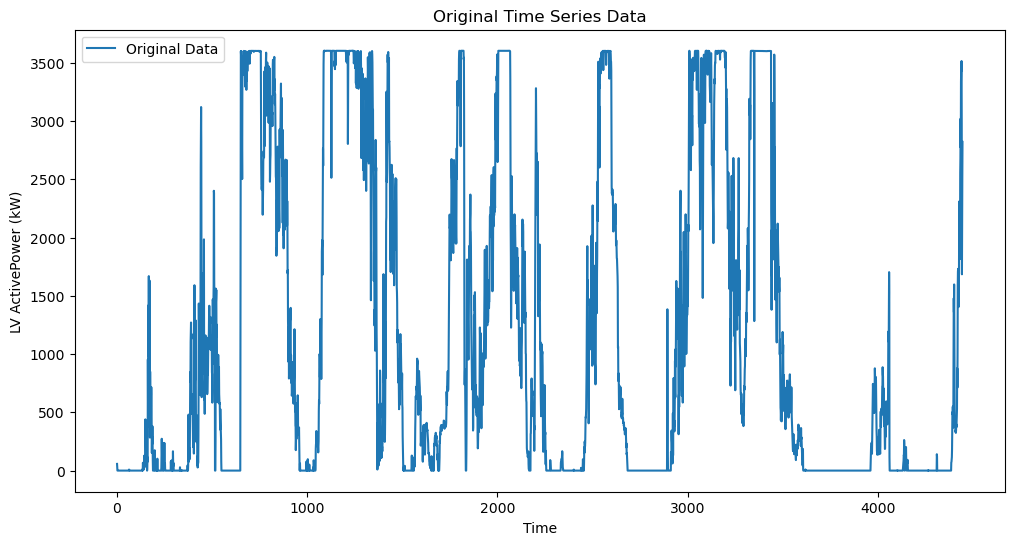

In [688]:
# Plot the original time series data
plt.figure(figsize=(12, 6))
plt.plot(data_new.index, data_new.values, label='Original Data')
plt.title('Original Time Series Data')
plt.xlabel('Time')
plt.ylabel('LV ActivePower (kW)')
plt.legend()
plt.show()

((3557, 1), (890, 1))

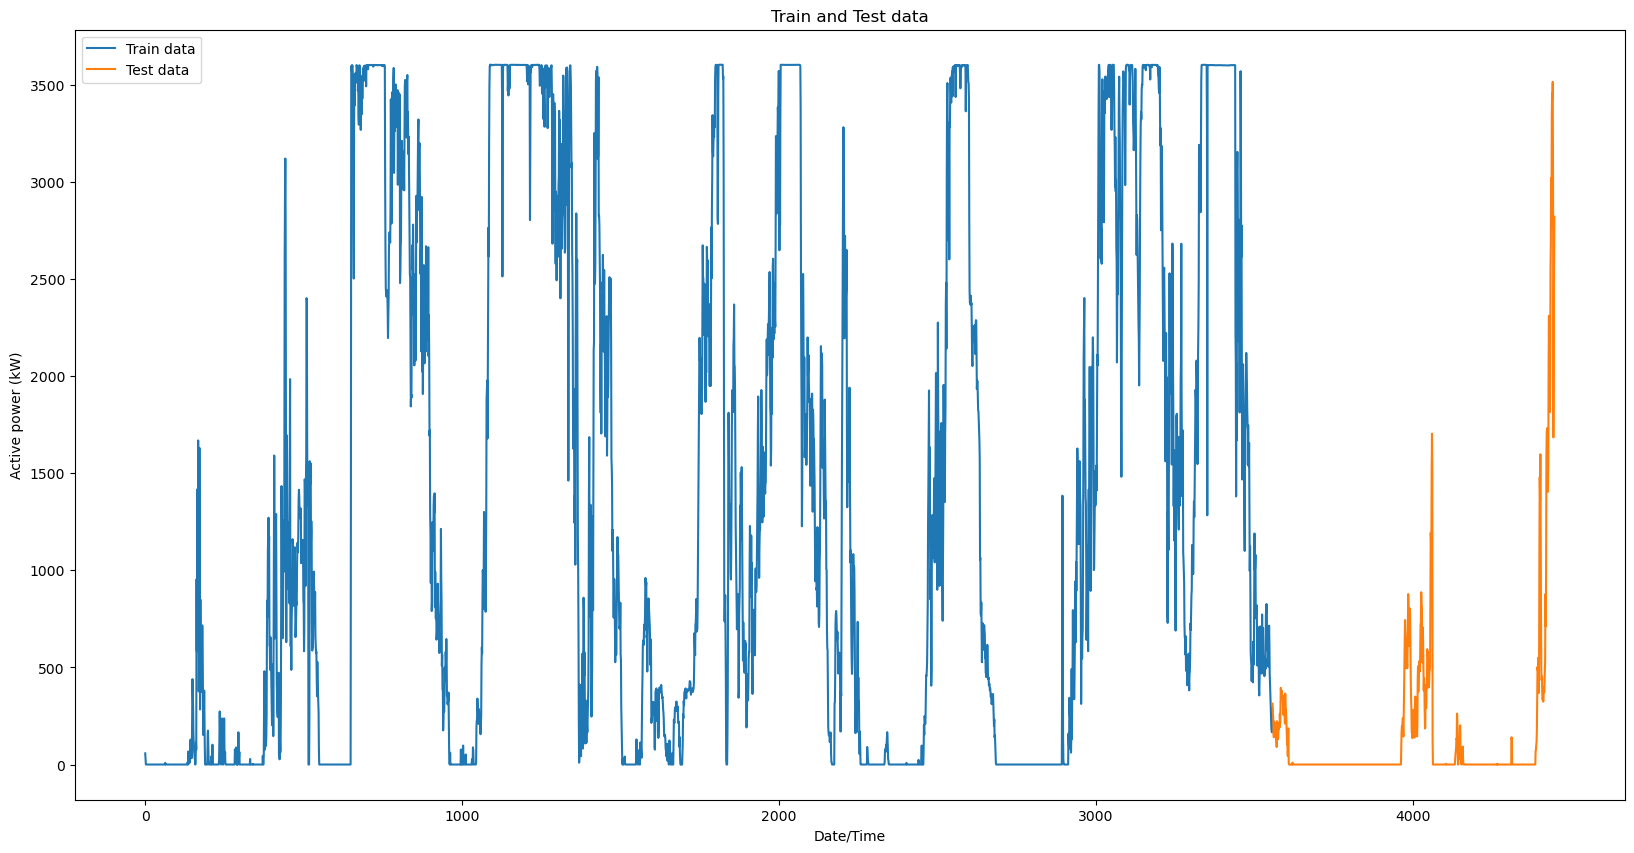

In [689]:
# split the data into training and testing data
train_size = int(len(data_new) * 0.80)
train_data, test_data = data_new.iloc[:train_size], data_new.iloc[train_size:]

#plot the train and test data
plt.figure(figsize=(20, 10))
plt.plot(train_data.index, train_data['LV ActivePower (kW)'], label='Train data')
plt.plot(test_data.index, test_data['LV ActivePower (kW)'], label='Test data')
plt.title('Train and Test data')
plt.xlabel('Date/Time')
plt.ylabel('Active power (kW)')
plt.legend()

# shape of the train and test data
train_data.shape, test_data.shape


In [690]:
def create_xy(data, input_length, output_length):
    """
    Generates input (x) and output (y) pairs from time series data based on the specified input and output lengths.

    Parameters:
    - data (np.ndarray or list): The time series data as a numpy array or list.
    - input_length (int): The number of time steps for the input sequence.
    - output_length (int): The number of time steps for the output sequence.

    Returns:
    - x (np.ndarray): The array of input sequences with shape (num_samples, input_length).
    - y (np.ndarray): The array of output sequences with shape (num_samples, output_length).
    """
    x, y = [], []
    total_length = len(data)

    # Iterate over the dataset to create input-output pairs
    for i in range(total_length - input_length - output_length + 1):
        x.append(data[i:i + input_length])
        y.append(data[i + input_length:i + input_length + output_length])
    
    return np.array(x), np.array(y)

In [691]:
# Convert the train and test data to NumPy arrays
train_data_np = train_data.values
test_data_np = test_data.values

# set the input and output lengths
input_length = 24
output_length = 6
# Get the X_train and y_train from the training data
X_train, y_train = create_xy(train_data_np, input_length, output_length)

# Get the X_test and y_test from the test data
X_test, y_test = create_xy(test_data_np, input_length, output_length)

# Print the shape of the training data and testing data
print(f"X_train shape: {X_train.shape}| y_train shape: {y_train.shape}") 
print(f"X_test shape: {X_test.shape}| y_test shape: {y_test.shape}") 

X_train shape: (3528, 24, 1)| y_train shape: (3528, 6, 1)
X_test shape: (861, 24, 1)| y_test shape: (861, 6, 1)


In [692]:
# reshape the X_train and X_test by removing the last dimension
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1])
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1])

# reshape the y_train and y_test by removing the last dimensions
y_train = y_train.reshape(y_train.shape[0], y_train.shape[1])
y_test = y_test.reshape(y_test.shape[0], y_test.shape[1])

# Print the shape of the training data and testing data
print(f"X_train shape: {X_train.shape}| y_train shape: {y_train.shape}") # (num_samples, input_length) | (num_samples, output_length)
print(f"X_test shape: {X_test.shape}| y_test shape: {y_test.shape}") # (num_samples, input_length) | (num_samples, output_length)

X_train shape: (3528, 24)| y_train shape: (3528, 6)
X_test shape: (861, 24)| y_test shape: (861, 6)


In [693]:
# Scaling the data
scaler_x = MinMaxScaler(feature_range=(0, 1))
scaler_y = [MinMaxScaler(feature_range=(0, 1)) for _ in range(output_length)]

# Scale X_train and X_test
X_train_scaled = scaler_x.fit_transform(X_train)
X_test_scaled = scaler_x.transform(X_test)

# Scale y_train and y_test for each output step
y_train_scaled = np.hstack([
    scaler_y[i].fit_transform(y_train[:, i].reshape(-1, 1)) for i in range(output_length)
])
y_test_scaled = np.hstack([
    scaler_y[i].transform(y_test[:, i].reshape(-1, 1)) for i in range(output_length)
])


In [694]:
# Add a dimension to X_train_scaled and X_test_scaled
X_train = X_train_scaled[..., np.newaxis]
X_test = X_test_scaled[..., np.newaxis]


# Print the shape of the scaled training data and testing data
print(f"X_train_scaled shape: {X_train.shape}| y_train_scaled shape: {y_train.shape}") 
print(f"X_test_scaled shape: {X_test.shape}| y_test_scaled shape: {y_test.shape}") 

X_train_scaled shape: (3528, 24, 1)| y_train_scaled shape: (3528, 6)
X_test_scaled shape: (861, 24, 1)| y_test_scaled shape: (861, 6)


In [695]:
# Convert to tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_scaled, dtype=torch.float32)

In [696]:
# Setup data loaders for batch
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [697]:
# Shape of the data loaders
len(train_loader), len(test_loader)

(56, 14)

### Step 3: Building the models and Training them

## Section 1: building the model

In [698]:
# Positional Encoding for Transformer
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=5000):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(p=dropout)

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0).transpose(0, 1)
        self.register_buffer('pe', pe)

    def forward(self, x):
        x = x + self.pe[:x.size(0), :]
        return self.dropout(x)

In [699]:
import torch
import torch.nn as nn

# Enhanced Transformer Model for Multiple-Point Prediction
class TransformerModel(nn.Module):
    def __init__(self, input_dim=1, d_model=64, nhead=4, num_layers=2, 
                 dim_feedforward=256, dropout=0.2, output_seq_len=10):
        super(TransformerModel, self).__init__()

        self.encoder = nn.Linear(input_dim, d_model)
        self.pos_encoder = PositionalEncoding(d_model, dropout)
        
        # Transformer Encoder Layer with configurable dim_feedforward
        encoder_layers = nn.TransformerEncoderLayer(d_model, nhead, dim_feedforward=dim_feedforward, dropout=dropout)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layers, num_layers)
        
        # Decoder layer to project the final representation to output_seq_len
        self.decoder = nn.Linear(d_model, output_seq_len)

    def forward(self, x):
        # x shape: (batch_size, seq_len, input_dim)
        x = self.encoder(x)  # (batch_size, seq_len, d_model)
        x = self.pos_encoder(x)  # (batch_size, seq_len, d_model)
        x = self.transformer_encoder(x)  # (batch_size, seq_len, d_model)
        x = self.decoder(x[:, -1, :])  # Use the output of the last time step
        return x  # Output shape: (batch_size, output_seq_len)


# Device
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Instantiate the model with custom feedforward dimensions
model = TransformerModel(input_dim=1, d_model=64, nhead=4, num_layers=2,
                         dim_feedforward=256, dropout=0.2, output_seq_len=6).to(device)



c:\Users\aalma\anaconda3\Lib\site-packages\torch\nn\modules\transformer.py:307: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


In [700]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = ReduceLROnPlateau(optimizer, 'min', factor=0.5, patience=3, verbose=True)

c:\Users\aalma\anaconda3\Lib\site-packages\torch\optim\lr_scheduler.py:60: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


## Section 2: Training the models

In [701]:
from tqdm.auto import tqdm
import numpy as np


# Training Loop
epochs = 30
for epoch in tqdm(range(epochs)):
    model.train()
    train_losses = []
    for x_batch, y_batch in train_loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        x_batch = x_batch.view(x_batch.size(0), -1, 1)
        outputs = model(x_batch)
        loss = criterion(outputs, y_batch)
        train_losses.append(loss.item())
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # Validation
    model.eval()
    val_losses = []
    with torch.no_grad():
        for x_batch, y_batch in test_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            x_batch = x_batch.view(x_batch.size(0), -1, 1)
            outputs = model(x_batch)
            loss = criterion(outputs, y_batch)
            val_losses.append(loss.item())

    avg_train_loss = np.mean(train_losses)
    avg_val_loss = np.mean(val_losses)
    scheduler.step(avg_val_loss)
    print(f"Epoch {epoch + 1}/{epochs} - Train Loss: {avg_train_loss:.4f}, Validation Loss: {avg_val_loss:.4f}")

  0%|          | 0/30 [00:00<?, ?it/s]

Epoch 1/30 - Train Loss: 0.1021, Validation Loss: 0.0075
Epoch 2/30 - Train Loss: 0.0336, Validation Loss: 0.0083
Epoch 3/30 - Train Loss: 0.0287, Validation Loss: 0.0073
Epoch 4/30 - Train Loss: 0.0246, Validation Loss: 0.0105
Epoch 5/30 - Train Loss: 0.0211, Validation Loss: 0.0093
Epoch 6/30 - Train Loss: 0.0208, Validation Loss: 0.0118
Epoch 7/30 - Train Loss: 0.0208, Validation Loss: 0.0070
Epoch 8/30 - Train Loss: 0.0201, Validation Loss: 0.0090
Epoch 9/30 - Train Loss: 0.0186, Validation Loss: 0.0064
Epoch 10/30 - Train Loss: 0.0191, Validation Loss: 0.0110
Epoch 11/30 - Train Loss: 0.0184, Validation Loss: 0.0102
Epoch 12/30 - Train Loss: 0.0176, Validation Loss: 0.0090
Epoch 13/30 - Train Loss: 0.0175, Validation Loss: 0.0115
Epoch 14/30 - Train Loss: 0.0165, Validation Loss: 0.0095
Epoch 15/30 - Train Loss: 0.0167, Validation Loss: 0.0095
Epoch 16/30 - Train Loss: 0.0161, Validation Loss: 0.0099
Epoch 17/30 - Train Loss: 0.0161, Validation Loss: 0.0072
Epoch 18/30 - Train Los

In [702]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np


# Evaluation
model.eval()
predictions, actuals = [], []
with torch.no_grad():
    for x_batch, y_batch in test_loader:
        x_batch = x_batch.to(device).view(x_batch.size(0), -1, 1)
        outputs = model(x_batch)
        predictions.append(outputs.cpu().numpy())
        actuals.append(y_batch.cpu().numpy())

predictions = np.concatenate(predictions, axis=0)
actuals = np.concatenate(actuals, axis=0)

# Inverse transform
predictions_inv = np.hstack([
    scaler_y[i].inverse_transform(predictions[:, i].reshape(-1, 1)) for i in range(output_length)
])
actuals_inv = np.hstack([
    scaler_y[i].inverse_transform(actuals[:, i].reshape(-1, 1)) for i in range(output_length)
])

# Compute metrics
rmse = np.sqrt(mean_squared_error(actuals_inv, predictions_inv))
mae = mean_absolute_error(actuals_inv, predictions_inv)
r2 = r2_score(actuals_inv, predictions_inv)

print(f"Score (RMSE): {rmse:.3f}")
print(f"Score (MAE): {mae:.3f}")
print(f"Score (R^2): {r2:.3f}")


Score (RMSE): 319.345
Score (MAE): 279.749
Score (R^2): 0.484


In [703]:
import matplotlib.pyplot as plt
import numpy as np

def plot_predictions_comparison(actual, prediction, model_name, num_points=1000, output_seq_len=2):
    """
    Plots the comparison of actual vs. predicted values for multi-step time series forecasting.

    Parameters:
    - actual (np.ndarray): Array of actual values (num_samples, output_seq_len).
    - prediction (np.ndarray): Array of predicted values (num_samples, output_seq_len).
    - model_name (str): Name of the model for the title.
    - num_points (int): Number of points to display in the plot.
    - output_seq_len (int): Number of time steps being predicted (multi-step).
    """
    plt.figure(figsize=(18, 8))  # Larger figure size for better visibility
    
    # Flatten the actual and prediction arrays for plotting
    actual_flat = actual[:num_points].reshape(-1)
    prediction_flat = prediction[:num_points].reshape(-1)

    # Plot actual values
    plt.plot(actual_flat, label='Actual Values', color='blue', linewidth=2)

    # Plot predictions
    plt.plot(prediction_flat, label='Predicted Values', color='orange', linestyle='--', linewidth=2)

    # Highlight error regions with shading
    error = np.abs(actual_flat - prediction_flat)
    plt.fill_between(range(len(actual_flat)), actual_flat, prediction_flat, color='gray', alpha=0.3, label='Error Region')

    # Add titles and labels
    plt.title(f'Actual vs Predictions ({model_name}) - First {num_points} Points', fontsize=14)
    plt.xlabel('Time Steps', fontsize=12)
    plt.ylabel('Values', fontsize=12)
    plt.legend(fontsize=10)
    plt.grid(True, linestyle='--', alpha=0.5)

    # Show the plot
    plt.tight_layout()
    plt.show()


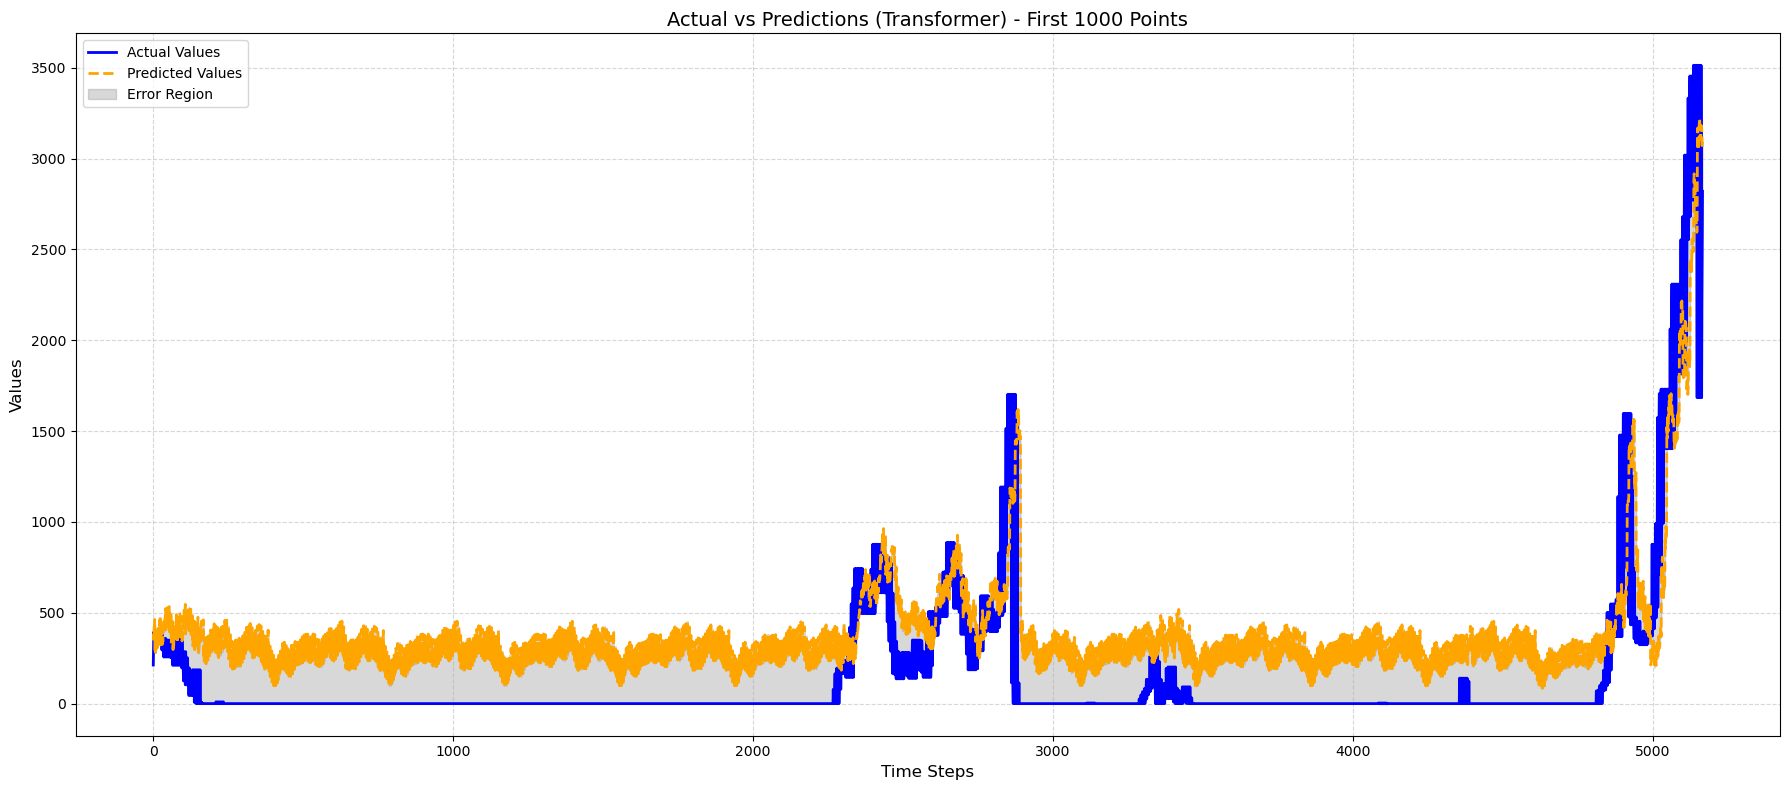

In [704]:
# Assume predictions_inv and actuals_inv are the inverse-scaled results
plot_predictions_comparison(actuals_inv, predictions_inv, model_name='Transformer', num_points=1000, output_seq_len=2)
